In [1]:
import pandas as pd
import numpy as np
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras.layers import Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
(X_train, y_train),(X_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
X_train.shape

(60000, 28, 28)

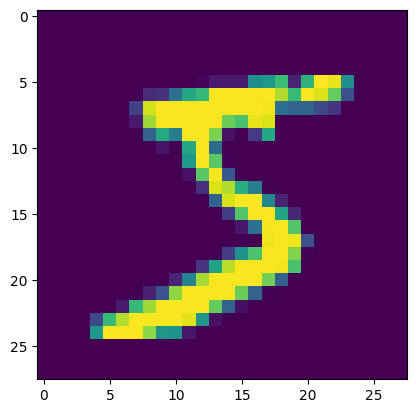

In [4]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0])

In [5]:
y_train[0]

np.uint8(5)

In [6]:
X_train = X_train/255
X_test = X_test/255

In [7]:
model = Sequential()
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [10]:
history = model.fit(X_train,y_train,epochs=10,validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9186 - loss: 0.2865 - val_accuracy: 0.9562 - val_loss: 0.1543
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9618 - loss: 0.1298 - val_accuracy: 0.9666 - val_loss: 0.1172
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9741 - loss: 0.0871 - val_accuracy: 0.9691 - val_loss: 0.1028
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9800 - loss: 0.0656 - val_accuracy: 0.9716 - val_loss: 0.0973
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9851 - loss: 0.0500 - val_accuracy: 0.9734 - val_loss: 0.0877
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9878 - loss: 0.0392 - val_accuracy: 0.9748 - val_loss: 0.0888
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9911 - loss: 0.0307 - val_accuracy: 0.9740 - val_loss: 0.0871
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9928 - loss: 0.0255 - 

In [11]:
y_prob = model.predict(X_test)
y_prob[1]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([2.1797031e-10, 1.6037276e-06, 9.9999797e-01, 5.0383318e-07,
       1.4144664e-18, 1.1160123e-08, 2.6482903e-09, 2.5768848e-14,
       1.6544790e-08, 1.3908558e-16], dtype=float32)

In [12]:
y_pred = np.argmax(y_prob, axis=1)
y_pred

array([7, 2, 1, ..., 4, 5, 6])

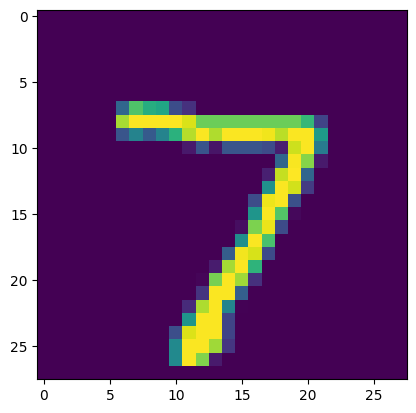

In [13]:
plt.imshow(X_test[0])

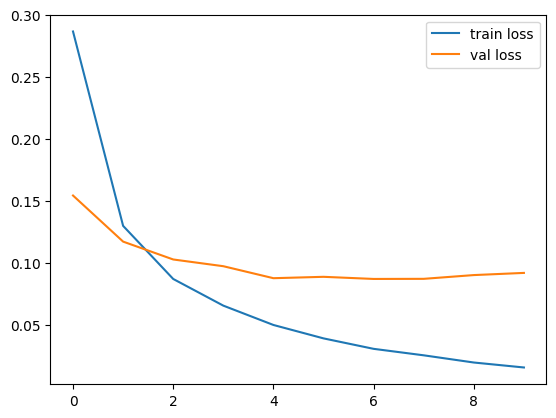

In [14]:
plt.plot(history.history['loss'],label='train loss')
plt.plot(history.history['val_loss'],label='val loss')
plt.legend()
plt.show()

In [15]:
print(accuracy_score(y_test,y_pred))

0.9761


## Training using Dropout

In [16]:
model_dropout = Sequential()

model_dropout.add(Flatten(input_shape=(28,28)))
model_dropout.add(Dense(128,activation='relu'))
model_dropout.add(Dropout(0.2))
model_dropout.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
model_dropout.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model_dropout.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [19]:
history = model_dropout.fit(X_train,y_train,epochs=10,validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9056 - loss: 0.3284 - val_accuracy: 0.9520 - val_loss: 0.1616
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9521 - loss: 0.1618 - val_accuracy: 0.9664 - val_loss: 0.1203
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9638 - loss: 0.1197 - val_accuracy: 0.9703 - val_loss: 0.1015
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9705 - loss: 0.0975 - val_accuracy: 0.9712 - val_loss: 0.0948
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9749 - loss: 0.0811 - val_accuracy: 0.9744 - val_loss: 0.0846
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9776 - loss: 0.0698 - val_accuracy: 0.9752 - val_loss: 0.0787
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9803 - loss: 0.0621 - val_accuracy: 0.9770 - val_loss: 0.0836
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9826 - loss: 0.0551 - 

In [20]:
y_prob = model_dropout.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)
y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([7, 2, 1, ..., 4, 5, 6])

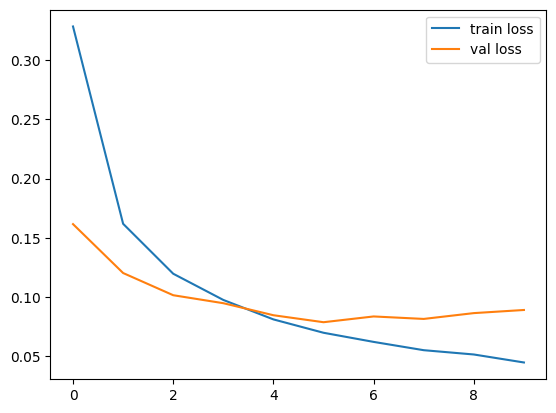

In [21]:
plt.plot(history.history['loss'],label='train loss')
plt.plot(history.history['val_loss'],label='val loss')
plt.legend()
plt.show()

In [22]:
print(accuracy_score(y_test,y_pred))

0.9782


## Combining early stopping with dropout

In [23]:
from tensorflow.keras.callbacks import EarlyStopping

In [24]:
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=2,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=True,
)

In [33]:
model_dropout_es = Sequential()

model_dropout_es.add(Flatten(input_shape=(28,28)))
model_dropout_es.add(Dense(128,activation='relu'))
model_dropout_es.add(Dropout(0.2))
model_dropout_es.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [34]:
model_dropout_es.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [35]:
history_es = model_dropout_es.fit(X_train,y_train,epochs=10,validation_split=0.2,callbacks=callback)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9050 - loss: 0.3282 - val_accuracy: 0.9528 - val_loss: 0.1664
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9509 - loss: 0.1644 - val_accuracy: 0.9653 - val_loss: 0.1182
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9637 - loss: 0.1224 - val_accuracy: 0.9696 - val_loss: 0.1028
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9695 - loss: 0.0992 - val_accuracy: 0.9728 - val_loss: 0.0900
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9750 - loss: 0.0820 - val_accuracy: 0.9738 - val_loss: 0.0873
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9772 - loss: 0.0718 - val_accuracy: 0.9741 - val_loss: 0.0882
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9793 - loss: 0.0638 - val_accuracy: 0.9748 - val_loss: 0.0829
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9820 - loss: 0.0559 - 

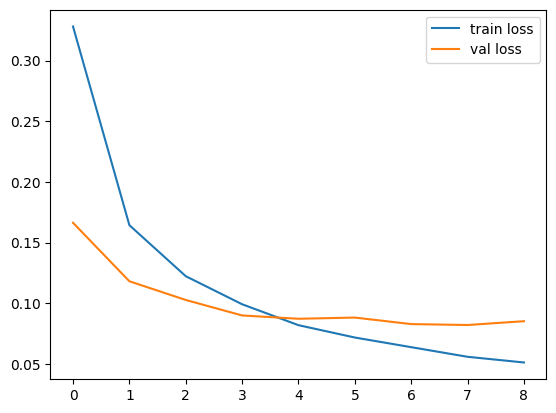

In [36]:
plt.plot(history_es.history['loss'],label='train loss')
plt.plot(history_es.history['val_loss'],label='val loss')
plt.legend()
plt.show()

In [37]:
y_pred = np.argmax(model_dropout_es.predict(X_test),axis=1)
print(accuracy_score(y_test,y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
0.9762
